In [118]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------
# Pfade
# --------------------------------------------------
BASE_RAR = "/content/drive/MyDrive/dm-effect-analysis-RAR_clean"
DATA_RAR = BASE_RAR + "/data"
FIG_RAR = BASE_RAR + "/figures"

ROT_PATH = "/content/drive/MyDrive/dm-effect-analysis/data/sparc/rotmod"
Q_PATH = "/content/drive/MyDrive/dm-effect-analysis/data/sparc/q_fit_results.csv"

os.makedirs(DATA_RAR, exist_ok=True)
os.makedirs(FIG_RAR, exist_ok=True)

# --------------------------------------------------
# ROTMOD laden
# --------------------------------------------------
files = glob.glob(ROT_PATH + "/*.dat")
if len(files) == 0:
    raise FileNotFoundError(f"Keine .dat-Dateien gefunden in {ROT_PATH}")

all_data = []

for f in files:
    try:
        df = pd.read_csv(
            f,
            sep=r"\s+",
            header=None,
            comment="#",
            engine="python"
        )

        if df.shape[1] < 6:
            continue

        df = df.iloc[:, :8].copy()

        while df.shape[1] < 8:
            df[df.shape[1]] = pd.NA

        df.columns = ["r", "Vobs", "errV", "Vgas", "Vdisk", "Vbul", "col7", "col8"]
        df["galaxy"] = Path(f).stem.replace("_rotmod", "")

        for col in ["r", "Vobs", "Vgas", "Vdisk", "Vbul"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        df = df.dropna(subset=["r", "Vobs", "Vgas", "Vdisk", "Vbul"])
        df = df[df["r"] > 0]

        if len(df) > 0:
            all_data.append(df)

    except Exception:
        continue

if len(all_data) == 0:
    raise ValueError("Keine verwertbaren ROTMOD-Daten geladen.")

df = pd.concat(all_data, ignore_index=True)

# --------------------------------------------------
# RAR berechnen
# --------------------------------------------------
df["g_obs"] = df["Vobs"]**2 / df["r"]
df["g_bar"] = (df["Vgas"]**2 + df["Vdisk"]**2 + df["Vbul"]**2) / df["r"]

rar_data = df[["galaxy", "g_bar", "g_obs"]].dropna().copy()

# --------------------------------------------------
# Globaler Fit
# --------------------------------------------------
x = np.log10(rar_data["g_bar"])
y = np.log10(rar_data["g_obs"])

slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept
r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)

# --------------------------------------------------
# q laden und mergen
# --------------------------------------------------
q_df = pd.read_csv(Q_PATH)
q_df["galaxy"] = q_df["filename"].str.replace("_rotmod.dat", "", regex=False)

rar_q = pd.merge(rar_data, q_df, on="galaxy", how="left")

def classify_q(q):
    if pd.isna(q):
        return np.nan
    if q < 1.2:
        return "Peak"
    elif q > 2.5:
        return "Diffus"
    return "Transition"

rar_q["regime_q"] = rar_q["q"].apply(classify_q)
rar_q["D"] = rar_q["g_obs"] / rar_q["g_bar"]

# --------------------------------------------------
# kurze Kontrolle
# --------------------------------------------------
print("RAR points:", len(rar_data))
print("Slope:", slope)
print("R²:", r2)
print(rar_q["regime_q"].value_counts(dropna=False))

RAR points: 3391
Slope: 0.6693209257487138
R²: 0.8628156906339599
regime_q
Peak          2033
Diffus         890
Transition     403
NaN             65
Name: count, dtype: int64


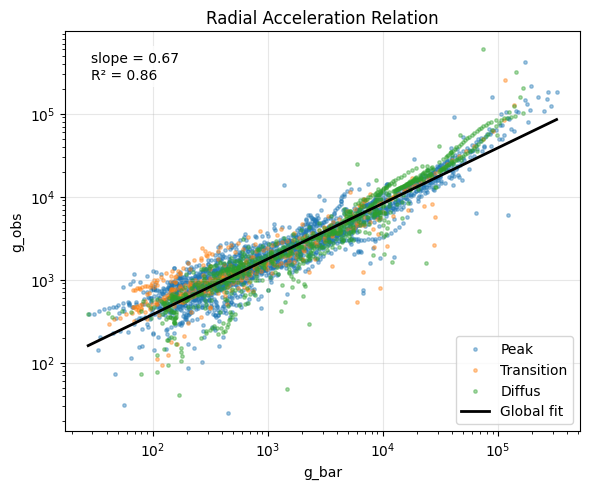

In [119]:
plt.figure(figsize=(6,5))

colors = {
    "Peak": "#1f77b4",
    "Transition": "#ff7f0e",
    "Diffus": "#2ca02c"
}

for regime in ["Peak", "Transition", "Diffus"]:
    sub = rar_q[rar_q["regime_q"] == regime]
    plt.scatter(
        sub["g_bar"],
        sub["g_obs"],
        s=6,
        alpha=0.4,
        color=colors[regime],
        label=regime
    )

x_line = np.logspace(
    np.log10(rar_data["g_bar"].min()),
    np.log10(rar_data["g_bar"].max()),
    200
)
y_line = 10**intercept * x_line**slope

plt.plot(x_line, y_line, color="black", linewidth=2, label="Global fit")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("g_bar")
plt.ylabel("g_obs")
plt.title("Radial Acceleration Relation")

plt.text(
    0.05, 0.95,
    f"slope = {slope:.2f}\nR² = {r2:.2f}",
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(FIG_RAR + "/fig1_rar_final.png", dpi=300, bbox_inches="tight")
plt.show()

In [120]:
rar_data.to_csv(DATA_RAR + "/rar_data.csv", index=False)
rar_q.to_csv(DATA_RAR + "/rar_q_merged.csv", index=False)

rar_summary = pd.DataFrame({
    "slope": [slope],
    "intercept": [intercept],
    "r2": [r2],
    "n_points": [len(rar_data)]
})

rar_summary.to_csv(DATA_RAR + "/rar_summary.csv", index=False)

print("Gespeichert:")
print("-", DATA_RAR + "/rar_data.csv")
print("-", DATA_RAR + "/rar_q_merged.csv")
print("-", DATA_RAR + "/rar_summary.csv")
print("-", FIG_RAR + "/fig1_rar_final.png")

Gespeichert:
- /content/drive/MyDrive/dm-effect-analysis-RAR_clean/data/rar_data.csv
- /content/drive/MyDrive/dm-effect-analysis-RAR_clean/data/rar_q_merged.csv
- /content/drive/MyDrive/dm-effect-analysis-RAR_clean/data/rar_summary.csv
- /content/drive/MyDrive/dm-effect-analysis-RAR_clean/figures/fig1_rar_final.png
